# Create a Recovery Cell (Run First in Every Session)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/Banana_Project/dataset"
PROJECT_PATH = "/content/drive/MyDrive/Banana_Project"

Mounted at /content/drive


# 1 Data Preperation

STEP 1: Download Dataset from Roboflow

In [ ]:
!pip install roboflow

Connect Roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="4b9qHSOuNM3Sb7962u9Q")
project = rf.workspace("naveens-workspace-4cbjf").project("banana-ripeness-classification-zu69u")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to banana-ripeness-classification-1 in folder:: 100%|██████████| 13480/13480 [00:01<00:00, 10611.15it/s]


STEP 2: Verify Dataset Structure

In [ ]:
import os

dataset_path = dataset.location

for folder in os.listdir(dataset_path):
    print(folder)

test
README.roboflow.txt
README.dataset.txt
valid
train


STEP 3: Check Classes

In [ ]:
train_path = dataset_path + "/train"

classes = os.listdir(train_path)

print(classes)
print("Total Classes:", len(classes))

['overripe', 'rotten', 'unripe', 'ripe']
Total Classes: 4


STEP 4: Class Distribution Analysis

In [ ]:
import pandas as pd

data = []

for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    data.append([cls, count])

df = pd.DataFrame(data, columns=["Class", "Images"])

df

,Class,Images
0,overripe,2349
1,rotten,4020
2,unripe,1902
3,ripe,3522


Plot Distribution

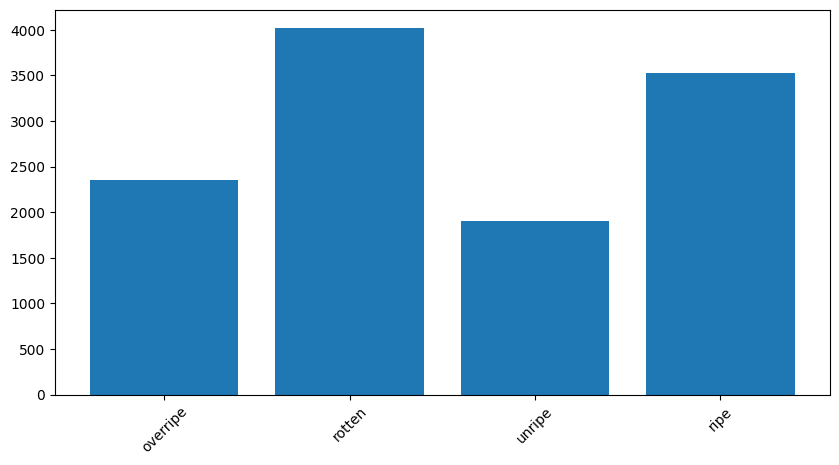

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=45)
plt.show()

STEP 5: Display Sample Images

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

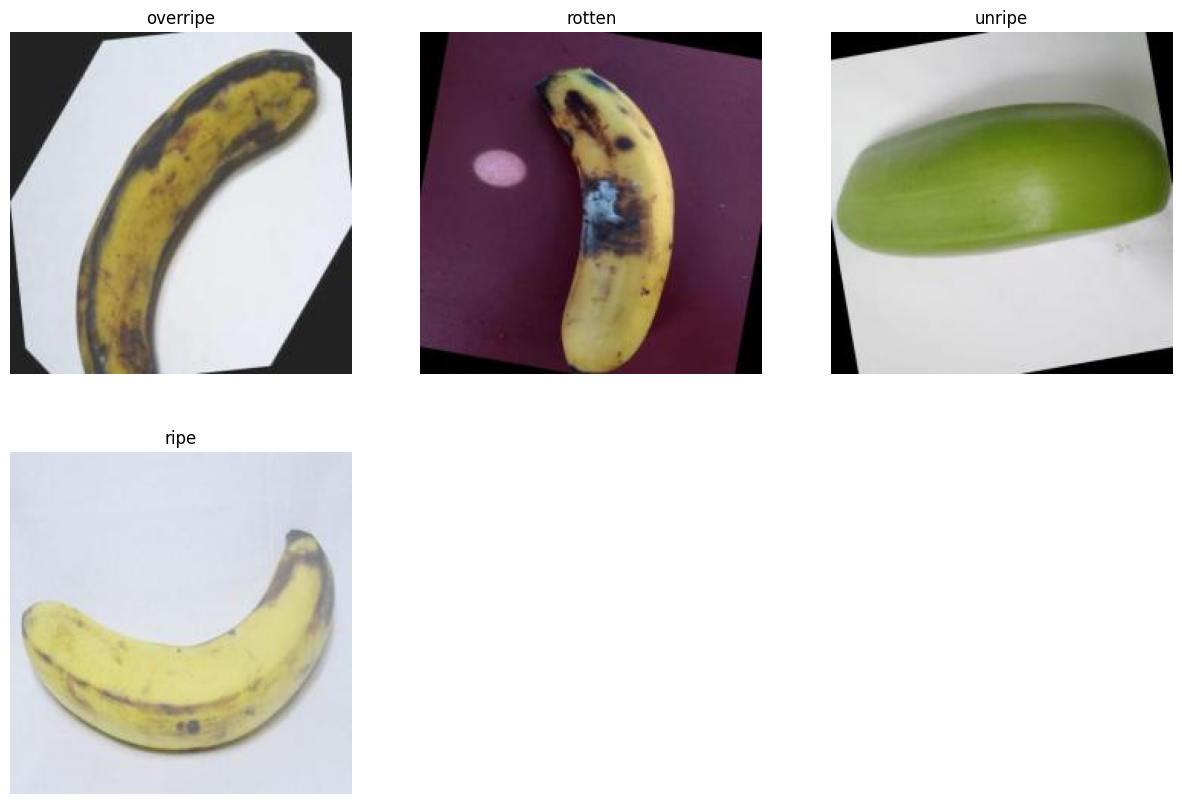

In [ ]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:6]):

    img_path = os.path.join(
        train_path,
        cls,
        random.choice(os.listdir(os.path.join(train_path, cls)))
    )

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

STEP 6: Check Image Size

In [ ]:
from PIL import Image

sample = Image.open(img_path)

sample.size

(224, 224)

STEP 7: Detect Corrupted Images

In [ ]:
from PIL import Image
import os

bad_images = []

for cls in classes:

    folder = os.path.join(train_path, cls)

    for img in os.listdir(folder):

        path = os.path.join(folder, img)

        try:
            Image.open(path).verify()

        except:
            bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


STEP 8: Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

STEP 9: Create Data Generators

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    dataset_path + "/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

print(train_generator.class_indices)
print("Number of Classes:", len(train_generator.class_indices))

Found 11793 images belonging to 4 classes.
{'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}
Number of Classes: 4


In [ ]:
train_generator.class_indices

{'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}

# Step 2: Build the Custom CNN (Baseline Model)

Install TensorFlow

In [ ]:
!pip install tensorflow

Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

Create Validation Generator

In [ ]:
val_generator = val_datagen.flow_from_directory(
    dataset_path + "/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1123 images belonging to 4 classes.


Build Custom CNN

In [ ]:
custom_cnn = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Compile

In [ ]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

View Architecture

In [ ]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,267,268 (73.50 MB)

 Trainable params: 19,266,308 (73.50 MB)

 Non-trainable params: 960 (3.75 KB)

Train Model

In [ ]:
history = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 177s 437ms/step - accuracy: 0.7244 - loss: 2.8064 - val_accuracy: 0.5592 - val_loss: 1.3001
Epoch 2/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 155s 420ms/step - accuracy: 0.8175 - loss: 0.5836 - val_accuracy: 0.8655 - val_loss: 0.3598
Epoch 3/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 203s 422ms/step - accuracy: 0.8364 - loss: 0.4798 - val_accuracy: 0.8985 - val_loss: 0.2752
Epoch 4/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 155s 421ms/step - accuracy: 0.8544 - loss: 0.4288 - val_accuracy: 0.8700 - val_loss: 0.4815
Epoch 5/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 153s 414ms/step - accuracy: 0.8441 - loss: 0.4495 - val_accuracy: 0.7703 - val_loss: 1.5105
Epoch 6/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 152s 411ms/step - accuracy: 0.8642 - loss: 0.4045 - val_accuracy: 0.8353 - val_loss: 0.4460
Epoch 7/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 153s 415ms/step - accuracy: 0.8680 - loss: 0.4022 - val_accuracy: 0.7257 - val_loss: 1.5366
Epoch 8/15
369/369 ━━━━━━━━━━━━━━━━━━━━ 150s 406ms/step - accuracy: 0.8703 -

Save Model

In [ ]:
custom_cnn.save("custom_cnn_model.keras")

Plot Accuracy

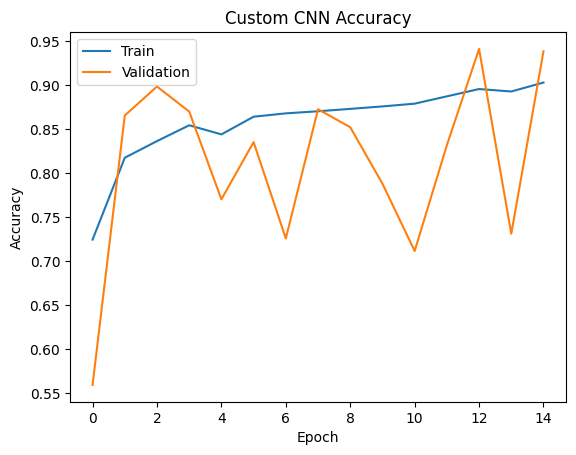

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

Plot Loss

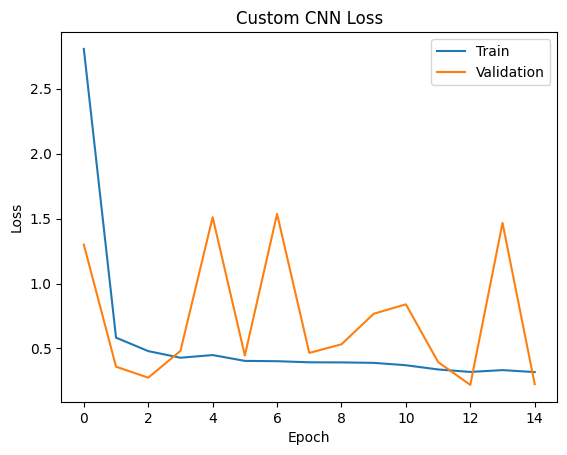

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
print(max(history.history['val_accuracy']))

0.9412288665771484


Upload the Model Back to Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving custom_cnn_model.keras to custom_cnn_model.keras


In [ ]:
from tensorflow.keras.models import load_model

custom_cnn = load_model("custom_cnn_model.keras")

In [ ]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,799,886 (220.49 MB)

 Trainable params: 19,266,308 (73.50 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 38,532,618 (146.99 MB)

In [ ]:
print(dataset_path)

/content/banana-ripeness-classification-1


In [ ]:
import os

print(os.listdir(dataset_path))

['test', 'README.roboflow.txt', 'README.dataset.txt', 'valid', 'train']


In [ ]:
import os

print(os.path.exists(dataset_path + "/test"))
print(os.listdir(dataset_path + "/test"))

True
['overripe', 'rotten', 'unripe', 'ripe']


In [ ]:
test_generator = val_datagen.flow_from_directory(
    dataset_path + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 562 images belonging to 4 classes.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving custom_cnn_model.keras to custom_cnn_model.keras


In [ ]:
from tensorflow.keras.models import load_model

custom_cnn = load_model("custom_cnn_model.keras")

In [ ]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,799,886 (220.49 MB)

 Trainable params: 19,266,308 (73.50 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 38,532,618 (146.99 MB)

In [ ]:
test_loss, test_acc = custom_cnn.evaluate(test_generator)

print("Test Accuracy:", test_acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9342 - loss: 0.2084
Test Accuracy: 0.9341636896133423


Generate Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

pred = custom_cnn.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step
              precision    recall  f1-score   support

    overripe       0.95      0.90      0.93       113
        ripe       0.88      0.97      0.92       154
      rotten       0.96      0.90      0.93       185
      unripe       0.96      0.97      0.97       110

    accuracy                           0.93       562
   macro avg       0.94      0.94      0.94       562
weighted avg       0.94      0.93      0.93       562



Generate Confusion Matrix

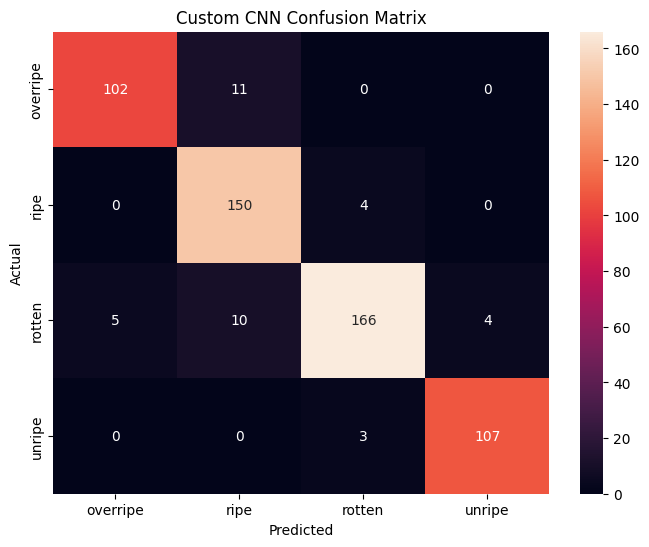

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# MobileNetV2 (Notebook 03)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "mobilenetv2_best.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
print(train_generator)
print(val_generator)
print(mobilenet_model)

<Functional name=functional_16, built=True>


In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 192s 469ms/step - accuracy: 0.8960 - loss: 0.2954 - val_accuracy: 0.9501 - val_loss: 0.1529
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 144s 391ms/step - accuracy: 0.9359 - loss: 0.1828 - val_accuracy: 0.9519 - val_loss: 0.1362
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 142s 386ms/step - accuracy: 0.9439 - loss: 0.1513 - val_accuracy: 0.9635 - val_loss: 0.1210
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 143s 386ms/step - accuracy: 0.9495 - loss: 0.1478 - val_accuracy: 0.9724 - val_loss: 0.1008
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 142s 384ms/step - accuracy: 0.9557 - loss: 0.1238 - val_accuracy: 0.9608 - val_loss: 0.1183
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 144s 392ms/step - accuracy: 0.9572 - loss: 0.1207 - val_accuracy: 0.9590 - val_loss: 0.1148
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 145s 391ms/step - accuracy: 0.9572 - loss: 0.1204 - val_accuracy: 0.9679 - val_loss: 0.0878
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 144s 391ms/step - accuracy: 0.9597 -

1. Model Summary

In [ ]:
mobilenet_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,244,878 (12.38 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 657,930 (2.51 MB)

2. Best Validation Accuracy

In [ ]:
print("Best Validation Accuracy:",
      max(history_mobilenet.history['val_accuracy']))

Best Validation Accuracy: 0.9723953604698181


In [ ]:
print(f"{max(history_mobilenet.history['val_accuracy'])*100:.2f}%")

97.24%


3. Test Accuracy

In [ ]:
test_loss, test_acc = mobilenet_model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 769ms/step - accuracy: 0.9698 - loss: 0.0804
Test Accuracy: 0.9697508811950684


In [ ]:
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 96.98%


4. Save the Model

In [ ]:
mobilenet_model.save("mobilenetv2_model.keras")

In [ ]:
from google.colab import files
files.download("mobilenetv2_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5. Plot Accuracy & Loss

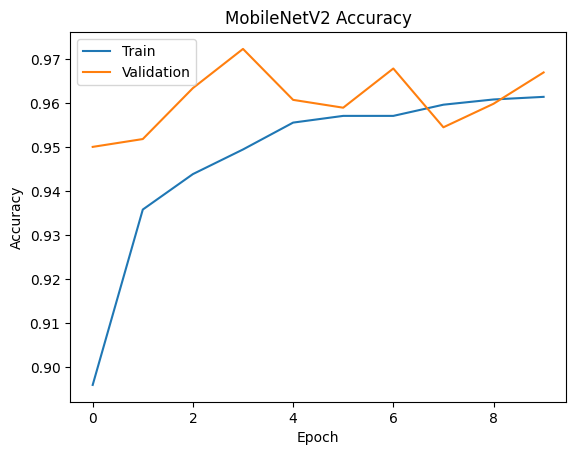

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

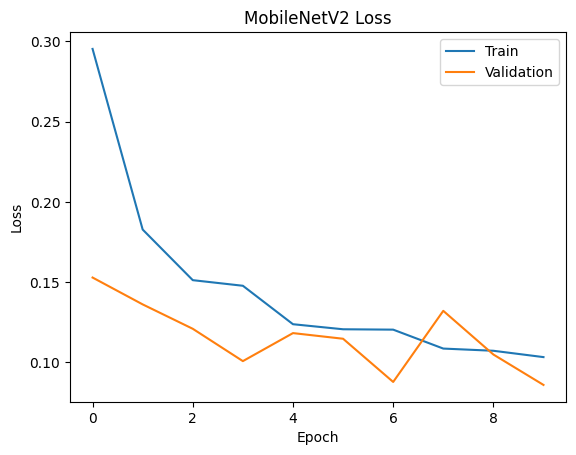

In [ ]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

# Next Model: EfficientNetB0

Build Model

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Recreate Only Missing Objects

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
dataset_path = dataset.location
print(dataset_path)

/content/banana-ripeness-classification-1


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create Project Folder in Drive

In [ ]:
import os

project_dir = "/content/drive/MyDrive/Banana_Project"

os.makedirs(project_dir, exist_ok=True)

print(project_dir)

/content/drive/MyDrive/Banana_Project


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving custom_cnn_model.keras to custom_cnn_model.keras
Saving mobilenetv2_model.keras to mobilenetv2_model.keras


Move Uploaded Files to Google Drive

In [ ]:
import shutil

for filename in uploaded.keys():
    shutil.move(
        filename,
        f"/content/drive/MyDrive/Banana_Project/{filename}"
    )

print("Models copied to Google Drive")

Models copied to Google Drive


In [ ]:
!ls "/content/drive/MyDrive/Banana_Project"

custom_cnn_model.keras	mobilenetv2_model.keras


Load Models Directly from Drive

In [ ]:
from tensorflow.keras.models import load_model

custom_cnn = load_model(
    "/content/drive/MyDrive/Banana_Project/custom_cnn_model.keras"
)

In [ ]:
mobilenet_model = load_model(
    "/content/drive/MyDrive/Banana_Project/mobilenetv2_model.keras"
)

Keep Dataset in Drive Too

In [ ]:
import shutil

shutil.copytree(
    dataset.location,
    "/content/drive/MyDrive/Banana_Project/dataset",
    dirs_exist_ok=True
)

'/content/drive/MyDrive/Banana_Project/dataset'

In [ ]:
dataset_path = "/content/drive/MyDrive/Banana_Project/dataset"

Train EfficientNetB0

In [ ]:
history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 261s 621ms/step - accuracy: 0.3257 - loss: 1.3587 - val_accuracy: 0.3455 - val_loss: 1.3402
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 185s 503ms/step - accuracy: 0.3392 - loss: 1.3499 - val_accuracy: 0.3455 - val_loss: 1.3401
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 189s 510ms/step - accuracy: 0.3409 - loss: 1.3486 - val_accuracy: 0.3455 - val_loss: 1.3394
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 186s 504ms/step - accuracy: 0.3409 - loss: 1.3461 - val_accuracy: 0.3455 - val_loss: 1.3372
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 187s 506ms/step - accuracy: 0.3409 - loss: 1.3461 - val_accuracy: 0.3455 - val_loss: 1.3388
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 185s 502ms/step - accuracy: 0.3409 - loss: 1.3445 - val_accuracy: 0.3455 - val_loss: 1.3382
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 185s 502ms/step - accuracy: 0.3409 - loss: 1.3447 - val_accuracy: 0.3455 - val_loss: 1.3369
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 200s 498ms/step - accuracy: 0.3409 -

In [ ]:
efficientnet_model.save(
    PROJECT_PATH + "/efficientnet_model.keras"
)

In [ ]:
import pickle

with open(
    PROJECT_PATH + "/history_efficientnet.pkl",
    "wb"
) as f:
    pickle.dump(history_efficientnet.history, f)

In [ ]:
efficientnet_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,036,465 (19.21 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 657,930 (2.51 MB)

In [ ]:
best_val_acc = max(history_efficientnet.history['val_accuracy'])

print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")

Best Validation Accuracy: 34.55%


In [ ]:
test_loss, test_acc = efficientnet_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.3292 - loss: 1.3704
Test Accuracy: 32.92%


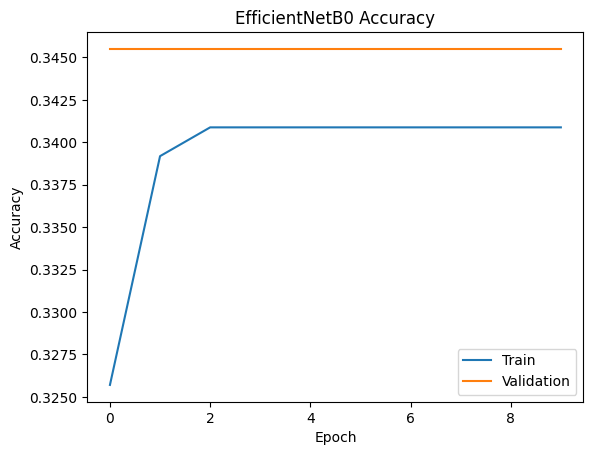

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_efficientnet.history['accuracy'])
plt.plot(history_efficientnet.history['val_accuracy'])
plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

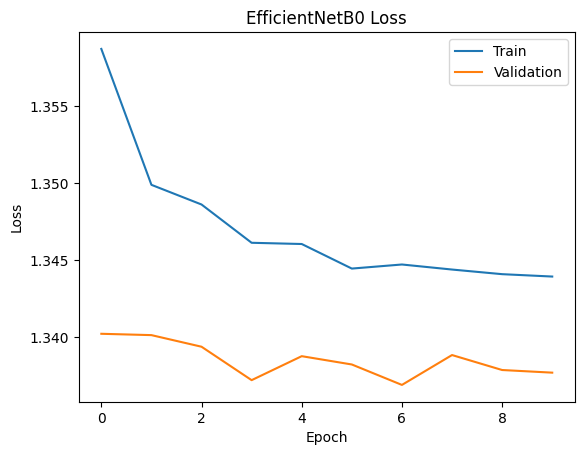

In [ ]:
plt.plot(history_efficientnet.history['loss'])
plt.plot(history_efficientnet.history['val_loss'])
plt.title('EfficientNetB0 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
print(train_generator.class_indices)

print(history_efficientnet.history['accuracy'])

print(history_efficientnet.history['val_accuracy'])

{'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}
[0.32570168375968933, 0.3391842544078827, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769, 0.3408801853656769]
[0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562, 0.3455031216144562]


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator
val_generator
test_generator

Rebuild EfficientNet

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

369/369 ━━━━━━━━━━━━━━━━━━━━ 235s 579ms/step - accuracy: 0.3324 - loss: 1.3596 - val_accuracy: 0.3455 - val_loss: 1.3373


ResNet50 Setup

Import Libraries

In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Create ResNet50 Generators

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH + "/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    DATASET_PATH + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.


Build ResNet50 Model

In [8]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

Compile Model

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [ ]:
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Create Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    PROJECT_PATH + "/resnet50_best.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "/train",
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical'
)

Found 11793 images belonging to 4 classes.


Sanity Check (1 Epoch First)

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 3959s 21s/step - accuracy: 0.9103 - loss: 0.2614 - val_accuracy: 0.9662 - val_loss: 0.1190
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2346s 13s/step - accuracy: 0.9529 - loss: 0.1323 - val_accuracy: 0.9786 - val_loss: 0.0919
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2380s 13s/step - accuracy: 0.9648 - loss: 0.1082 - val_accuracy: 0.9733 - val_loss: 0.0825
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2355s 13s/step - accuracy: 0.9674 - loss: 0.0920 - val_accuracy: 0.9813 - val_loss: 0.0678
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2321s 13s/step - accuracy: 0.9681 - loss: 0.0895 - val_accuracy: 0.9786 - val_loss: 0.0743
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2331s 13s/step - accuracy: 0.9740 - loss: 0.0782 - val_accuracy: 0.9831 - val_loss: 0.0628
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2334s 13s/step - accuracy: 0.9720 - loss: 0.0749 - val_accuracy: 0.9831 - val_loss: 0.0582
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2326s 13s/step - accuracy: 0.9718 - loss: 0

In [ ]:
best_val_acc = max(history_resnet.history['val_accuracy'])

print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")

Best Validation Accuracy: 98.31%


In [ ]:
test_loss, test_acc = resnet_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 168s 10s/step - accuracy: 0.9751 - loss: 0.0761
Test Accuracy: 97.51%


In [ ]:
resnet_model.save(
    PROJECT_PATH + "/resnet50_model.keras"
)

1. Reload the model

In [14]:
from tensorflow.keras.models import load_model

resnet_model = load_model(
    "/content/drive/MyDrive/Banana_Project/resnet50_model.keras"
)

2. Recreate the test generator

In [16]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    DATASET_PATH + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 562 images belonging to 4 classes.


3. Re-evaluate the model

In [17]:
test_loss, test_acc = resnet_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 162s 9s/step - accuracy: 0.9751 - loss: 0.0761
Test Accuracy: 97.51%


4. Generate the classification report again

In [18]:
from sklearn.metrics import classification_report
import numpy as np

pred = resnet_model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 318ms/step
              precision    recall  f1-score   support

    overripe       0.98      0.93      0.95       113
        ripe       0.94      1.00      0.97       154
      rotten       0.99      0.97      0.98       185
      unripe       0.99      0.99      0.99       110

    accuracy                           0.98       562
   macro avg       0.98      0.97      0.97       562
weighted avg       0.98      0.98      0.98       562



5. Generate the confusion matrix again

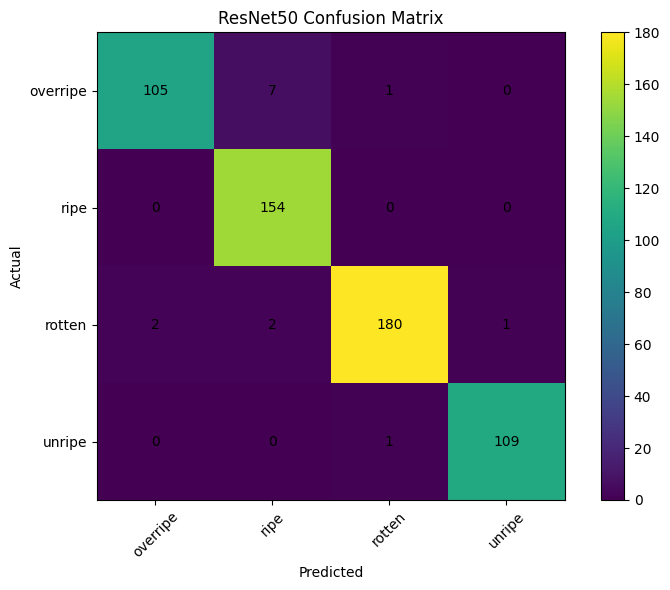

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.colorbar()

classes = list(test_generator.class_indices.keys())
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.tight_layout()
plt.show()

# YOLOv8 Classification

Install Ultralytics

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00


Import

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Load Pretrained Classification Model

In [4]:
model = YOLO("yolov8n-cls.pt")

Train

In [9]:
results = model.train(
    data=DATASET_PATH,
    epochs=10,
    imgsz=224,
    batch=32,
    project=PROJECT_PATH,
    name="YOLOv8_Classification"
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Banana_Project/dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Classification-2, nbs=64, nms=False, opset=Non

Step 6: Validate

In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/Banana_Project/dataset/train... found 11793 images in 4 classes ✅ 
val: /content/drive/MyDrive/Banana_Project/dataset/valid... found 1123 images in 4 classes ✅ 
test: /content/drive/MyDrive/Banana_Project/dataset/test... found 562 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 1.8±0.9 MB/s, size: 5.5 KB)
val: Scanning /content/drive/MyDrive/Banana_Project/dataset/valid... 1123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 174.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 71/71 2.7it/s 26.6s
                   all      0.989          1
Speed: 0.0ms preprocess, 14.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusio

Verify the folder structure

In [12]:
import os

print(os.listdir(DATASET_PATH + "/test"))

['overripe', 'rotten', 'unripe', 'ripe']


Predict on a Single Class Folder

In [13]:
results = model.predict(
    source=DATASET_PATH + "/test/ripe",
    save=True
)


image 1/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-ad772802-394a-11ec-996c-d8c4975e38aa_jpg.rf.269c0dd0868940e02689f6c3a37ebc94.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 114.1ms
image 2/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-adb78123-394a-11ec-93c6-d8c4975e38aa_jpg.rf.099d2610ec3c5240f65bddec388e4bfc.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 122.1ms
image 3/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-addcca4d-394a-11ec-b76c-d8c4975e38aa_jpg.rf.8a9d7ee7d3f3de6c90db80e3e080a858.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 95.9ms
image 4/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-adebf291-394a-11ec-99da-d8c4975e38aa_jpg.rf.c6b92d16939dd44f035bd8cacb8e83f6.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 73.9ms
image 5/154 /content/drive/MyDrive/Banana

Predict on a Single Image

In [14]:
import glob

img = glob.glob(DATASET_PATH + "/test/ripe/*.jpg")[0]

results = model.predict(
    source=img,
    save=True
)


image 1/1 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-freshripe-442acb3b-2653-11ec-a185-d8c4975e38aa_jpg.rf.ea7d0648a3231519cc11e41d31a34bc5.jpg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 28.3ms
Speed: 9.4ms preprocess, 28.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict


Validate the Model

In [15]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/Banana_Project/dataset/train... found 11793 images in 4 classes ✅ 
val: /content/drive/MyDrive/Banana_Project/dataset/valid... found 1123 images in 4 classes ✅ 
test: /content/drive/MyDrive/Banana_Project/dataset/test... found 562 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 9.2±19.3 ms, read: 2.2±1.1 MB/s, size: 5.5 KB)
val: Scanning /content/drive/MyDrive/Banana_Project/dataset/valid... 1123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 9.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 71/71 2.5it/s 28.5s
                   all      0.989          1
Speed: 0.0ms preprocess, 14.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-2
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e202c677950>
curves

Load Your Trained Model

In [17]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Banana_Project/YOLOv8_Classification-2/weights/best.pt")

Validate the Model

In [18]:
metrics = model.val(
    data=DATASET_PATH,
    imgsz=224
)

print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/Banana_Project/dataset/train... found 11793 images in 4 classes ✅ 
val: /content/drive/MyDrive/Banana_Project/dataset/valid... found 1123 images in 4 classes ✅ 
test: /content/drive/MyDrive/Banana_Project/dataset/test... found 562 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 5.2±9.6 ms, read: 0.4±0.3 MB/s, size: 5.5 KB)
val: Scanning /content/drive/MyDrive/Banana_Project/dataset/valid... 1123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 151.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 71/71 2.6it/s 26.9s
                   all      0.989          1
Speed: 0.0ms preprocess, 14.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-3
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confus

Predict on a Single Image

In [19]:
import glob

image = glob.glob(DATASET_PATH + "/test/ripe/*")[0]
print(image)

/content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-freshripe-442acb3b-2653-11ec-a185-d8c4975e38aa_jpg.rf.ea7d0648a3231519cc11e41d31a34bc5.jpg


In [20]:
results = model.predict(
    source=image,
    save=True
)


image 1/1 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-freshripe-442acb3b-2653-11ec-a185-d8c4975e38aa_jpg.rf.ea7d0648a3231519cc11e41d31a34bc5.jpg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 32.2ms
Speed: 7.0ms preprocess, 32.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict-2


Predict on All Images in One Class

In [21]:
results = model.predict(
    source=DATASET_PATH + "/test/ripe",
    save=True
)


image 1/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-ad772802-394a-11ec-996c-d8c4975e38aa_jpg.rf.269c0dd0868940e02689f6c3a37ebc94.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 105.9ms
image 2/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-adb78123-394a-11ec-93c6-d8c4975e38aa_jpg.rf.099d2610ec3c5240f65bddec388e4bfc.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 74.2ms
image 3/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-addcca4d-394a-11ec-b76c-d8c4975e38aa_jpg.rf.8a9d7ee7d3f3de6c90db80e3e080a858.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 41.3ms
image 4/154 /content/drive/MyDrive/Banana_Project/dataset/test/ripe/musa-acuminata-banana-adebf291-394a-11ec-99da-d8c4975e38aa_jpg.rf.c6b92d16939dd44f035bd8cacb8e83f6.jpg: 224x224 ripe 1.00, rotten 0.00, unripe 0.00, overripe 0.00, 57.0ms
image 5/154 /content/drive/MyDrive/Banana_

In [23]:
DATASET_PATH + "/test/overripe"
DATASET_PATH + "/test/rotten"
DATASET_PATH + "/test/unripe"

'/content/drive/MyDrive/Banana_Project/dataset/test/unripe'

Evaluate the Entire Test Set

In [24]:
import os

classes = ["overripe", "ripe", "rotten", "unripe"]

for cls in classes:
    print(f"Predicting: {cls}")
    model.predict(
        source=f"{DATASET_PATH}/test/{cls}",
        save=True
    )

Predicting: overripe

image 1/113 /content/drive/MyDrive/Banana_Project/dataset/test/overripe/musa-acuminata-mold-e18cfd23-1d0a-11ec-87d5-d8c4975e38aa_jpg.rf.6b106ac315464a1891c97b5e7f6147a1.jpg: 224x224 overripe 1.00, ripe 0.00, rotten 0.00, unripe 0.00, 27.0ms
image 2/113 /content/drive/MyDrive/Banana_Project/dataset/test/overripe/musa-acuminata-mold-e1a4d2b8-1d0a-11ec-af1f-d8c4975e38aa_jpg.rf.f21d70a4f565f78b53d7eae3d67b13f9.jpg: 224x224 overripe 1.00, ripe 0.00, rotten 0.00, unripe 0.00, 49.3ms
image 3/113 /content/drive/MyDrive/Banana_Project/dataset/test/overripe/musa-acuminata-mold-e1ae5b43-1d0a-11ec-80fd-d8c4975e38aa_jpg.rf.9badfc9b9765bc2df21a0d6811e5cf0a.jpg: 224x224 overripe 1.00, ripe 0.00, rotten 0.00, unripe 0.00, 61.9ms
image 4/113 /content/drive/MyDrive/Banana_Project/dataset/test/overripe/musa-acuminata-mold-e1de067f-1d0a-11ec-bae6-d8c4975e38aa_jpg.rf.ab74b7ae0b6fbb7ec89eb01440506bfc.jpg: 224x224 overripe 0.99, ripe 0.01, rotten 0.00, unripe 0.00, 37.4ms
image 5/113 /c

In [25]:
metrics = model.val(data=DATASET_PATH, imgsz=224)
print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/Banana_Project/dataset/train... found 11793 images in 4 classes ✅ 
val: /content/drive/MyDrive/Banana_Project/dataset/valid... found 1123 images in 4 classes ✅ 
test: /content/drive/MyDrive/Banana_Project/dataset/test... found 562 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 2.3±3.9 ms, read: 1.9±1.6 MB/s, size: 5.5 KB)
val: Scanning /content/drive/MyDrive/Banana_Project/dataset/valid... 1123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 261.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 71/71 2.2it/s 32.3s
                   all      0.989          1
Speed: 0.0ms preprocess, 17.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-4
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e201b915520>
curve

In [26]:
!ls -R "/content/drive/MyDrive/Banana_Project"

Streaming output truncated to the last 5000 lines.
musa-acuminata-rotten-88b79fe1-2653-11ec-addd-d8c4975e38aa_jpg.rf.39f5962544de4324293e7bf9ee33105b.jpg
musa-acuminata-rotten-88b79fe1-2653-11ec-addd-d8c4975e38aa_jpg.rf.670c7bb6e61d94ff7932b9fe72f75a96.jpg
musa-acuminata-rotten-88b79fe1-2653-11ec-addd-d8c4975e38aa_jpg.rf.d12ddce7a93942581717235e2ea18716.jpg
musa-acuminata-rotten-88bc642a-2653-11ec-8890-d8c4975e38aa_jpg.rf.4809e59e1cd229e551698a7feb9f786b.jpg
musa-acuminata-rotten-88bc642a-2653-11ec-8890-d8c4975e38aa_jpg.rf.53fce67753d74e32462670994dc10b77.jpg
musa-acuminata-rotten-88bc642a-2653-11ec-8890-d8c4975e38aa_jpg.rf.786184a8d061799d4315f82eeda69b8f.jpg
musa-acuminata-rotten-88e40c8f-2653-11ec-89d6-d8c4975e38aa_jpg.rf.622303b1919f257c7b7cdad696cf410c.jpg
musa-acuminata-rotten-88e40c8f-2653-11ec-89d6-d8c4975e38aa_jpg.rf.6fd49719bf1b771022b965ec1bc9b657.jpg
musa-acuminata-rotten-88e40c8f-2653-11ec-89d6-d8c4975e38aa_jpg.rf.e721621bb8b56394d02a43057bdec692.jpg
musa-acuminata-rotten-

In [29]:
import shutil
import os

os.makedirs("/content/drive/MyDrive/Banana_Project/YOLO", exist_ok=True)

shutil.copy(
    "/content/drive/MyDrive/Banana_Project/YOLOv8_Classification-2/weights/best.pt",
    "/content/drive/MyDrive/Banana_Project/YOLO"
)

'/content/drive/MyDrive/Banana_Project/YOLO/best.pt'

In [30]:
shutil.copytree(
    "/content/runs/classify/val-4",
    "/content/drive/MyDrive/Banana_Project/YOLO/validation_results",
    dirs_exist_ok=True
)

'/content/drive/MyDrive/Banana_Project/YOLO/validation_results'